<a href="https://colab.research.google.com/github/sandeep7348/Assignment/blob/master/HSVSegementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

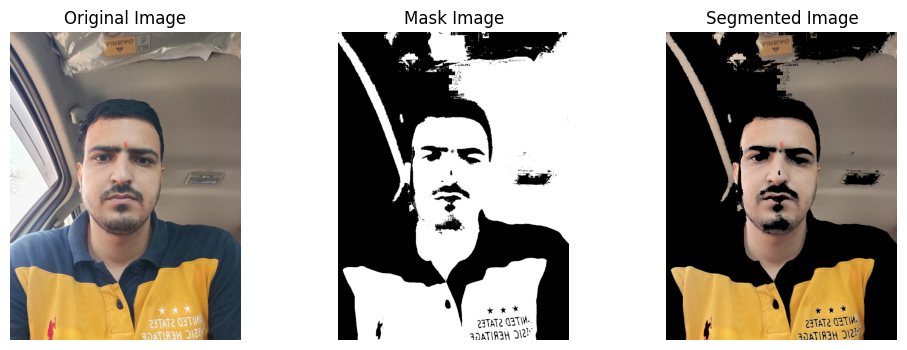

In [5]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def rgb_to_hsv(image):
    image = image.astype('float32') / 255.0
    r, g, b = image[:,:,0], image[:,:,1], image[:,:,2]

    cmax = np.max(image, axis=2)
    cmin = np.min(image, axis=2)
    diff = cmax - cmin

    h = np.zeros_like(cmax)

    mask = diff != 0

    idx = (cmax == r) & mask
    h[idx] = (60 * ((g[idx] - b[idx]) / diff[idx]) + 360) % 360

    idx = (cmax == g) & mask
    h[idx] = (60 * ((b[idx] - r[idx]) / diff[idx]) + 120) % 360

    idx = (cmax == b) & mask
    h[idx] = (60 * ((r[idx] - g[idx]) / diff[idx]) + 240) % 360

    s = np.zeros_like(cmax)
    s[cmax != 0] = diff[cmax != 0] / cmax[cmax != 0]

    v = cmax

    h = h / 2
    s = s * 255
    v = v * 255

    return np.stack([h, s, v], axis=2)

image = Image.open("selfieimage.jpeg").convert("RGB")
image_np = np.array(image)

hsv_image = rgb_to_hsv(image_np)

lower = np.array([0, 40, 50])
upper = np.array([25, 255, 255])

mask = np.all((hsv_image >= lower) & (hsv_image <= upper), axis=2)

segmented = np.zeros_like(image_np)
segmented[mask] = image_np[mask]

segmented = segmented.astype(np.uint8)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(image_np)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask, cmap='gray')
plt.title("Mask Image")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(segmented)
plt.title("Segmented Image")
plt.axis("off")

plt.show()